# Acoustic Feature Analysis — UA-SER

This notebook covers:
1. **Corpus statistics** — class balance, gender split, duration
2. **Acoustic feature extraction** — 34 handcrafted features per clip
3. **Kruskal-Wallis tests** — 34 features × 4 emotion classes, effect sizes
4. **Text/lexical analysis** — word count, TF-IDF discriminative words
5. **Visualisations** — all thesis-ready figures

In [1]:
import os, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
warnings.filterwarnings('ignore')

ANALYSIS_DIR = Path('.')
BASE_DIR     = ANALYSIS_DIR.parent
DATASET_CSV  = BASE_DIR / 'dataset.csv'
CLIPS_DIR    = BASE_DIR / 'clips'
FEATURES_CSV = ANALYSIS_DIR / 'features.csv'
FIGURES_DIR  = ANALYSIS_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

EMOTION_ORDER  = ['angry', 'happy', 'neutral', 'sad']
EMOTION_COLORS = {'angry': '#e74c3c', 'happy': '#f39c12', 'neutral': '#3498db', 'sad': '#8e44ad'}
EMOTION_PALETTE = [EMOTION_COLORS[e] for e in EMOTION_ORDER]

sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'serif', 'axes.titlesize': 14, 'axes.labelsize': 12,
})

def save(fig, name):
    fig.savefig(FIGURES_DIR / f'{name}.png', bbox_inches='tight')
    fig.savefig(FIGURES_DIR / f'{name}.pdf', bbox_inches='tight')
    plt.close(fig)
    print(f'  saved {name}.png / .pdf')

## 1. Load Dataset and Corpus Statistics

In [2]:
df = pd.read_csv(DATASET_CSV)
df['gender']     = df['filename'].str.extract(r'_(\d)\.wav$')[0].astype(int).map({0: 'male', 1: 'female'})
df['word_count'] = df['text'].fillna('').apply(lambda t: len(t.split()))

counts          = df['emotion'].value_counts().reindex(EMOTION_ORDER)
imbalance_ratio = counts.max() / counts.min()
total_dur_h     = df['duration_seconds'].sum() / 3600

print(f'Samples:         {len(df)}')
print(f'Total duration:  {total_dur_h:.2f} h')
print(f'Imbalance ratio: {imbalance_ratio:.2f}')
print(f'Female:          {(df["gender"]=="female").mean()*100:.1f}%')
print(f'Male:            {(df["gender"]=="male").mean()*100:.1f}%')
print()
print(counts.rename('count').to_frame())

Samples:         952
Total duration:  0.55 h
Imbalance ratio: 1.17
Female:          62.3%
Male:            37.7%

         count
emotion       
angry      259
happy      244
neutral    222
sad        227


In [3]:
# Class distribution + gender breakdown
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(EMOTION_ORDER, counts, color=EMOTION_PALETTE)
for i, v in enumerate(counts):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')
axes[0].set(ylabel='Number of Samples', title='Sample Count per Emotion')

cross = pd.crosstab(df['emotion'], df['gender']).reindex(EMOTION_ORDER)
x, w  = np.arange(len(EMOTION_ORDER)), 0.35
axes[1].bar(x - w/2, cross.get('female', 0), w, label='Female', color='#e88da0')
axes[1].bar(x + w/2, cross.get('male',   0), w, label='Male',   color='#6ca6cd')
axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTION_ORDER)
axes[1].set(ylabel='Number of Samples', title='Emotion × Gender Breakdown')
axes[1].legend()

gc = df['gender'].value_counts()
axes[2].pie(gc, labels=gc.index, autopct='%1.1f%%',
            colors=['#e88da0', '#6ca6cd'], startangle=90)
axes[2].set_title('Overall Gender Split')

fig.tight_layout()
save(fig, 'class_gender_distribution')

  saved class_gender_distribution.png / .pdf


Duration summary:
  median=1.99s  IQR=[1.53, 2.55]s
emotion
angry      1.790
happy      1.785
neutral    2.160
sad        2.200
Name: median_sec, dtype: float64


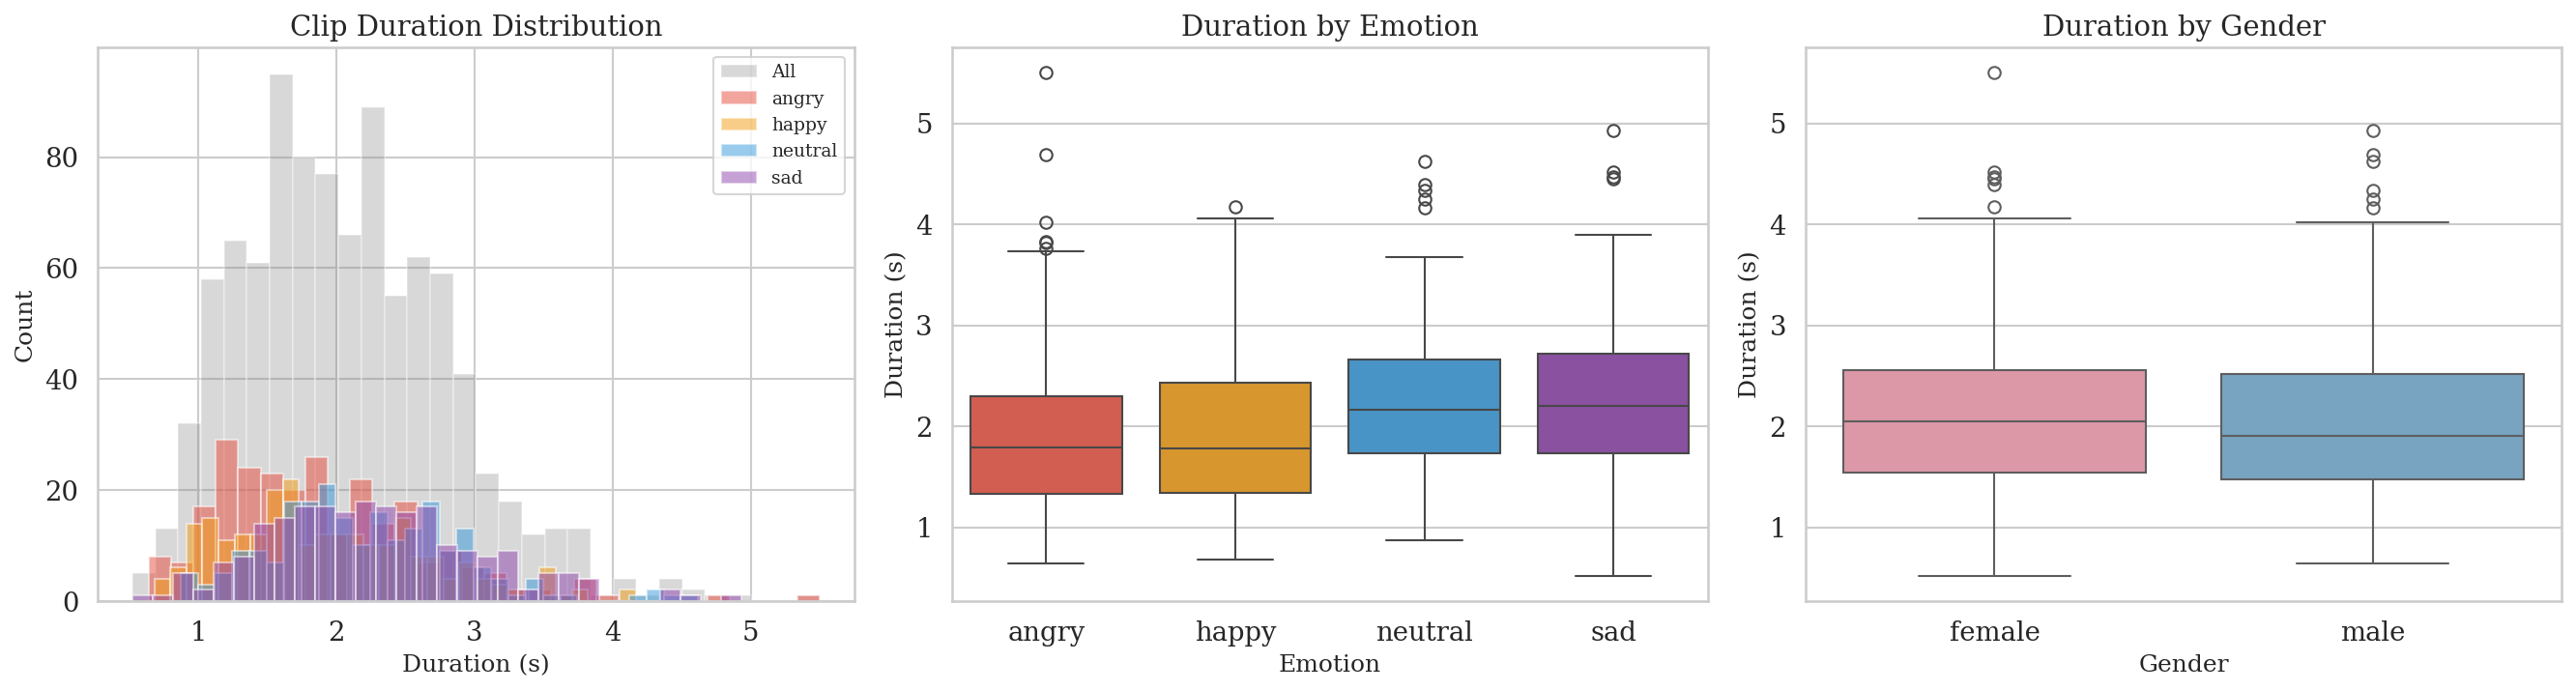

In [5]:
# Duration analysis
print('Duration summary:')
dur = df['duration_seconds']
print(f'  median={dur.median():.2f}s  IQR=[{dur.quantile(.25):.2f}, {dur.quantile(.75):.2f}]s')
print(df.groupby('emotion')['duration_seconds'].median().reindex(EMOTION_ORDER).rename('median_sec'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['duration_seconds'], bins=30, alpha=0.3, color='gray', label='All')
for emo in EMOTION_ORDER:
    axes[0].hist(df[df['emotion'] == emo]['duration_seconds'], bins=30,
                 alpha=0.5, color=EMOTION_COLORS[emo], label=emo)
axes[0].set(xlabel='Duration (s)', ylabel='Count', title='Clip Duration Distribution')
axes[0].legend(fontsize=9)

sns.boxplot(data=df, x='emotion', y='duration_seconds', order=EMOTION_ORDER,
            palette=EMOTION_PALETTE, ax=axes[1])
axes[1].set(xlabel='Emotion', ylabel='Duration (s)', title='Duration by Emotion')

sns.boxplot(data=df, x='gender', y='duration_seconds',
            palette={'female': '#e88da0', 'male': '#6ca6cd'}, ax=axes[2])
axes[2].set(xlabel='Gender', ylabel='Duration (s)', title='Duration by Gender')

fig.tight_layout()

In [ ]:
save(fig, 'duration_analysis')

## 2. Acoustic Feature Extraction

In [6]:
def extract_features(filepath):
    y, sr = librosa.load(filepath, sr=22050)
    feat  = {}

    f0, _, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
    f0_v = f0[~np.isnan(f0)]
    feat['pitch_mean'] = float(np.mean(f0_v))  if len(f0_v) > 0 else 0.0
    feat['pitch_std']  = float(np.std(f0_v))   if len(f0_v) > 0 else 0.0

    rms = librosa.feature.rms(y=y)[0]
    feat['energy_mean'] = float(np.mean(rms))
    feat['energy_std']  = float(np.std(rms))

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        feat[f'mfcc{i+1}_mean'] = float(np.mean(mfccs[i]))
        feat[f'mfcc{i+1}_std']  = float(np.std(mfccs[i]))

    feat['spectral_centroid_mean']   = float(np.mean(librosa.feature.spectral_centroid(y=y,   sr=sr)))
    feat['spectral_bandwidth_mean']  = float(np.mean(librosa.feature.spectral_bandwidth(y=y,  sr=sr)))
    feat['spectral_rolloff_mean']    = float(np.mean(librosa.feature.spectral_rolloff(y=y,    sr=sr)))
    feat['zcr_mean']                 = float(np.mean(librosa.feature.zero_crossing_rate(y)))
    return feat


def extract_all(df, clips_dir, cache_path):
    if Path(cache_path).exists():
        print(f'Loading cached features: {cache_path}')
        return pd.read_csv(cache_path)
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=str(clips_dir)):
        fpath = Path(clips_dir) / row['filename']
        if not fpath.exists():
            continue
        feat = extract_features(str(fpath))
        feat['filename'] = row['filename']
        records.append(feat)
    out = pd.DataFrame(records)
    out.to_csv(cache_path, index=False)
    print(f'Saved {cache_path}')
    return out


feat = extract_all(df, CLIPS_DIR, FEATURES_CSV)
master = df.merge(feat, on='filename')
feat_cols = [c for c in feat.columns if c != 'filename']
print(f'Features: {len(feat_cols)} | Samples: {len(master)}')

Loading cached features: features.csv
Features: 34 | Samples: 952


## 3. Kruskal-Wallis Tests + Effect Sizes

In [7]:
# Kruskal-Wallis for each feature, ε² effect size
# ε² = (H - k + 1) / (n - k)  where k = number of groups
groups  = [master[master['emotion'] == e][feat_cols].values for e in EMOTION_ORDER]
n_total = len(master)
k       = len(EMOTION_ORDER)

kw_results = []
for col in feat_cols:
    grp = [master[master['emotion'] == e][col].dropna().values for e in EMOTION_ORDER]
    H, p = stats.kruskal(*grp)
    eps2 = (H - k + 1) / (n_total - k)
    kw_results.append({'feature': col, 'H': H, 'p': p, 'eps2': eps2})

kw_df = pd.DataFrame(kw_results).sort_values('eps2', ascending=False)
n_sig = (kw_df['p'] < 0.05).sum()
print(f'Significant features (p < 0.05): {n_sig} / {len(kw_df)}')
print()
print('Top 10 features by effect size:')
display(kw_df.head(10)[['feature', 'H', 'p', 'eps2']].round(4))

Significant features (p < 0.05): 30 / 34

Top 10 features by effect size:


,feature,H,p,eps2
0,pitch_mean,155.0232,0.0,0.1604
7,mfcc2_std,126.7760,0.0,0.1306
2,energy_mean,108.1321,0.0,0.1109
6,mfcc2_mean,100.1256,0.0,0.1025
14,mfcc6_mean,86.0252,0.0,0.0876
16,mfcc7_mean,82.6175,0.0,0.0840
1,pitch_std,78.3575,0.0,0.0795
32,spectral_rolloff_mean,69.2546,0.0,0.0699
30,spectral_centroid_mean,68.3956,0.0,0.0690
8,mfcc3_mean,63.5659,0.0,0.0639


In [ ]:
top6 = kw_df.head(6)[['feature', 'H', 'eps2']].copy()
top6.columns = ['Feature', 'H', 'ε²']
print('Table: Top acoustic features ranked by Kruskal-Wallis effect size')
display(top6.reset_index(drop=True).round(3))

Table: Top acoustic features ranked by Kruskal-Wallis effect size


,Feature,H,ε²
0,pitch_mean,155.023,0.160
1,mfcc2_std,126.776,0.131
2,energy_mean,108.132,0.111
3,mfcc2_mean,100.126,0.102
4,mfcc6_mean,86.025,0.088
5,mfcc7_mean,82.618,0.084


## 4. Text / Lexical Analysis

In [9]:
# Lexical surface statistics
rows = []
for emo in EMOTION_ORDER:
    sub   = df[df['emotion'] == emo]
    texts = sub['text'].fillna('').tolist()
    words = [w for t in texts for w in t.split()]
    ttr   = len(set(words)) / len(words) if words else 0
    rows.append({
        'emotion':         emo,
        'mean_words/clip': sub['word_count'].mean(),
        'unique_vocab':    len(set(words)),
        'TTR':             ttr,
    })
display(pd.DataFrame(rows).set_index('emotion').round(2))

,mean_words/clip,unique_vocab,TTR
emotion,,,
angry,5.80,822,0.55
happy,4.37,664,0.62
neutral,5.55,834,0.68
sad,6.27,752,0.53


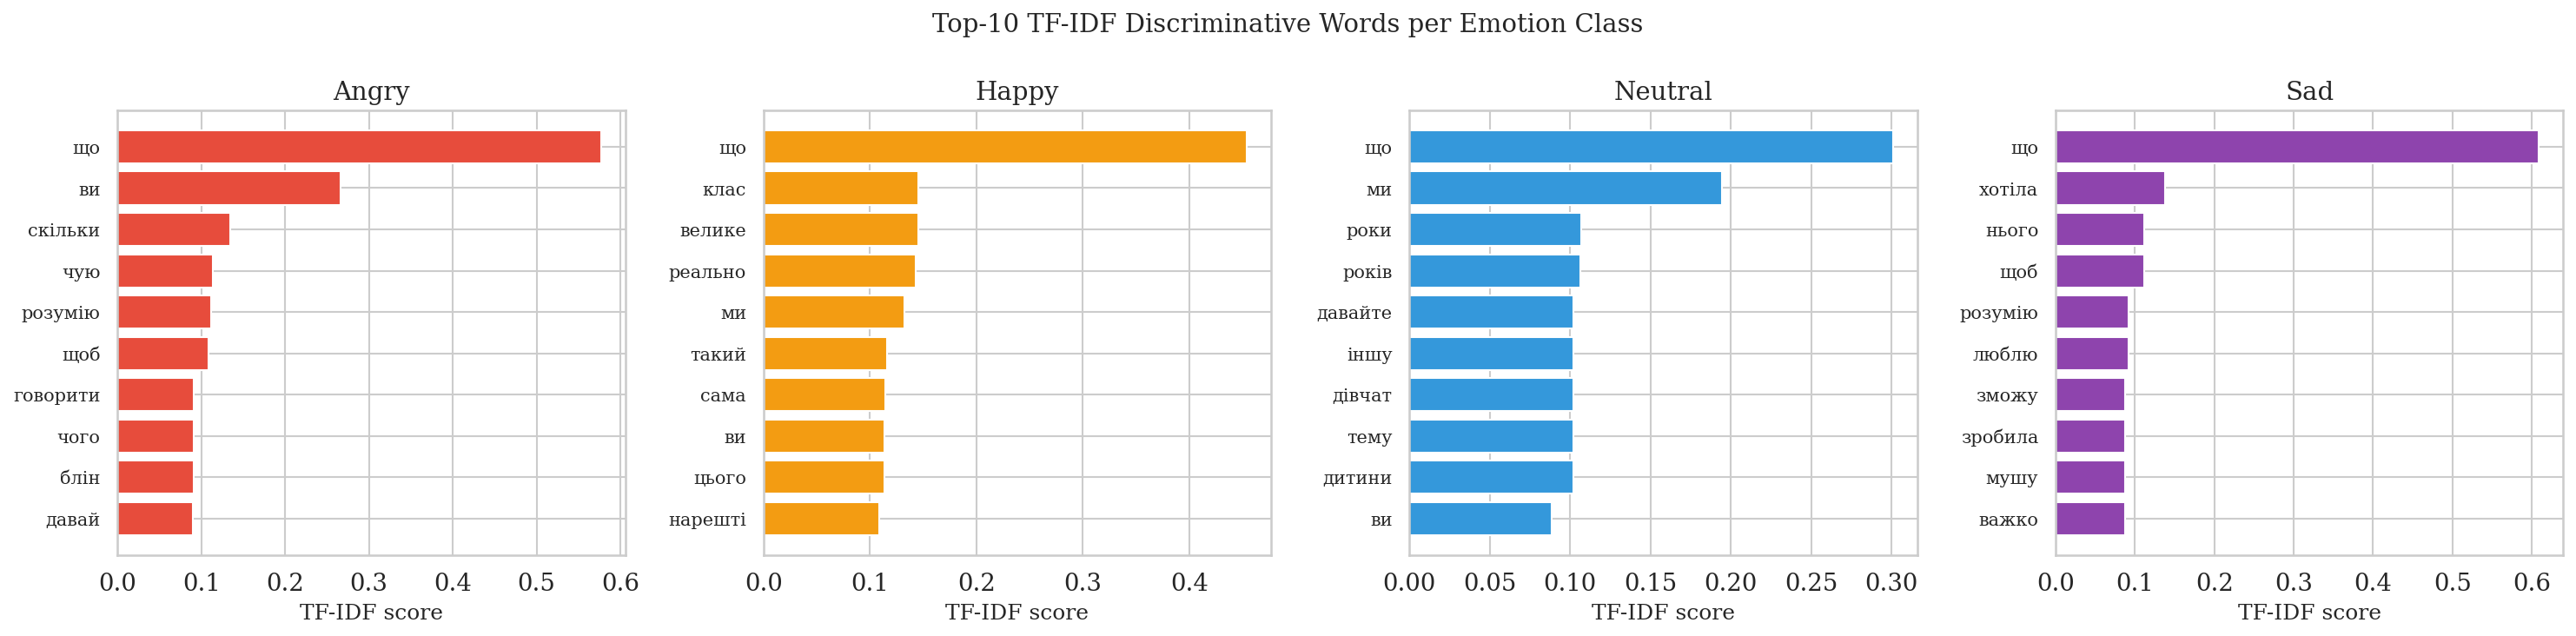

In [14]:
# TF-IDF discriminative words per class
from sklearn.feature_extraction.text import TfidfVectorizer

UA_STOP = set("""
а аби аж але аніж аж би бо без бути був була були було буде будемо будете будуть будь будьте
б ж же й і із іноді їх її її йому йде йдемо йти
в від він вона вони воно вже все всі всього всіх всьому вам вас ваш ваша ваше ваші
до де дуже два дві двох для досить дещо дійсно далі давно дехто дуже
та так там тобто тут то той тих тому тоді також тебе тобі твій твоя твоє твої ти треба
на нас нам не ні ну наш наша наше наші нічого нам немає ніхто них ними нею ним
з за зі зі зараз зовсім значить знову зокрема завжди
з'являється
к коли кого кому котрий котра котре котрі крім кілька
про при просто потім поки після під пере пора певний певна певне певні перший перша перше перші
між мені мене мені можна може можливо може міг могла могли могло мій моя моє мої мати мав мала мали мало
р раз разом різний різна різне різні
с ся слід своє своя свій свої собі себе ще
у цей ця цих це цьому цією цим хтось хто хоча хай хіба хоч якраз
я як якщо якби яки який яка яке які йому
є ну ось от він вона воно вони
тільки лише навіть саме ще вже дуже дещо також десь десь
по повністю поки потому при проте проти після поряд поряд
або однак одна один одне одні одного одній одним отже
їх їм їхній
бо адже тож отже отже тому
зараз тепер завжди
б мб може десь колись
маю маєш має маємо маєте мають мати
знаю знаєш знає знаємо знаєте знають
говорю говориш говорить говоримо говорите говорять
хочу хочеш хоче хочемо хочете хочуть
думаю думаєш думає думаємо думаєте думають
бачу бачиш бачить бачимо бачите бачать
розуміти
відчуваю відчуваєш відчуває відчуваємо відчуваєте відчувають
відчувала відчував відчувало
іду іде ідемо ідете ідуть
пішов пішла пішли
прийшов прийшла прийшли прийду
кажу кажеш каже кажемо кажете кажуть
казав казала казали
роблю робиш робить робимо робите роблять
робив робила робили
буду будеш буде будемо будете будуть
мусиш мусить мусимо мусите мусять мусів мусіла
хай нехай годі
отже власне
просто взагалі насправді взагалі принаймні наприклад зокрема передусім водночас
де куди звідки коли поки доки відтоді відколи
добре гаразд окей ок
дякую пробач вибач
тато мамо мама тату батько матір сестра брат
привіт здрастуй
так ні може
ага угу
люди народ
будь ласка
плакала плакав плакали
гарний гарна гарне гарні гарно
момент час рік
зараз нині сьогодні вчора завтра
хтось щось
ніщо нічого ніхто нікого
дещо дехто
усе все всі
треба слід варто потрібно
мабуть напевно певно
чому навіщо звідки
знову ще раз
тут там де
добрий добра добре добрі добро
може можна
""".split())


def clean(text):
    tokens = re.sub(r'[^\u0400-\u04FF\s]', ' ', str(text).lower()).split()
    return ' '.join(t for t in tokens if t not in UA_STOP and len(t) > 1)

docs_by_class = {}
for emo in EMOTION_ORDER:
    texts = df[df['emotion'] == emo]['text'].fillna('')
    docs_by_class[emo] = ' '.join(clean(t) for t in texts)

vect = TfidfVectorizer(max_features=2000)
tfidf = vect.fit_transform(docs_by_class.values())
vocab = np.array(vect.get_feature_names_out())

top_n = 10
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, emo in enumerate(EMOTION_ORDER):
    scores = tfidf[i].toarray().flatten()
    top_idx = np.argsort(scores)[-top_n:][::-1]
    top_words  = vocab[top_idx]
    top_scores = scores[top_idx]
    axes[i].barh(range(top_n), top_scores[::-1], color=EMOTION_COLORS[emo])
    axes[i].set_yticks(range(top_n))
    axes[i].set_yticklabels(top_words[::-1], fontsize=10)
    axes[i].set_title(emo.capitalize())
    axes[i].set_xlabel('TF-IDF score')

fig.suptitle('Top-10 TF-IDF Discriminative Words per Emotion Class', fontsize=14)
fig.tight_layout()


In [ ]:
save(fig, 'tfidf_discriminative_words')

## 5. Acoustic Visualisations

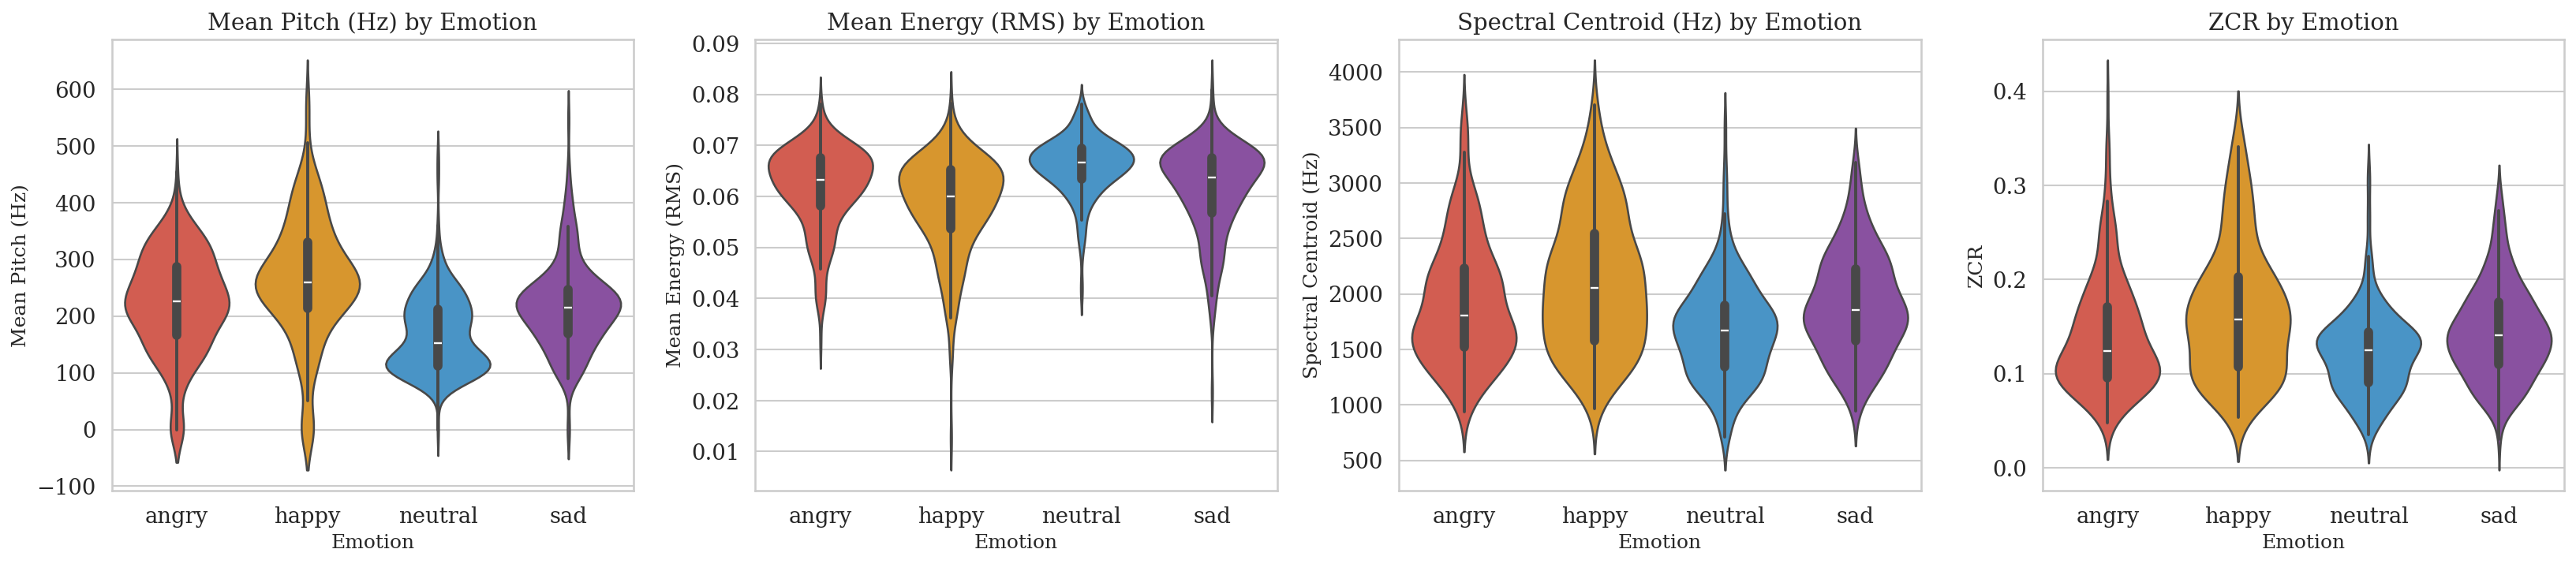

In [15]:
# Key features violin plot (pitch, energy, spectral centroid, ZCR)
key_feats = ['pitch_mean', 'energy_mean', 'spectral_centroid_mean', 'zcr_mean']
key_labels = ['Mean Pitch (Hz)', 'Mean Energy (RMS)', 'Spectral Centroid (Hz)', 'ZCR']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, feat_col, label in zip(axes, key_feats, key_labels):
    sns.violinplot(data=master, x='emotion', y=feat_col, order=EMOTION_ORDER,
                   palette=EMOTION_PALETTE, ax=ax, inner='box')
    ax.set(xlabel='Emotion', ylabel=label, title=label + ' by Emotion')
fig.tight_layout()


In [ ]:
save(fig, 'key_features_violin')

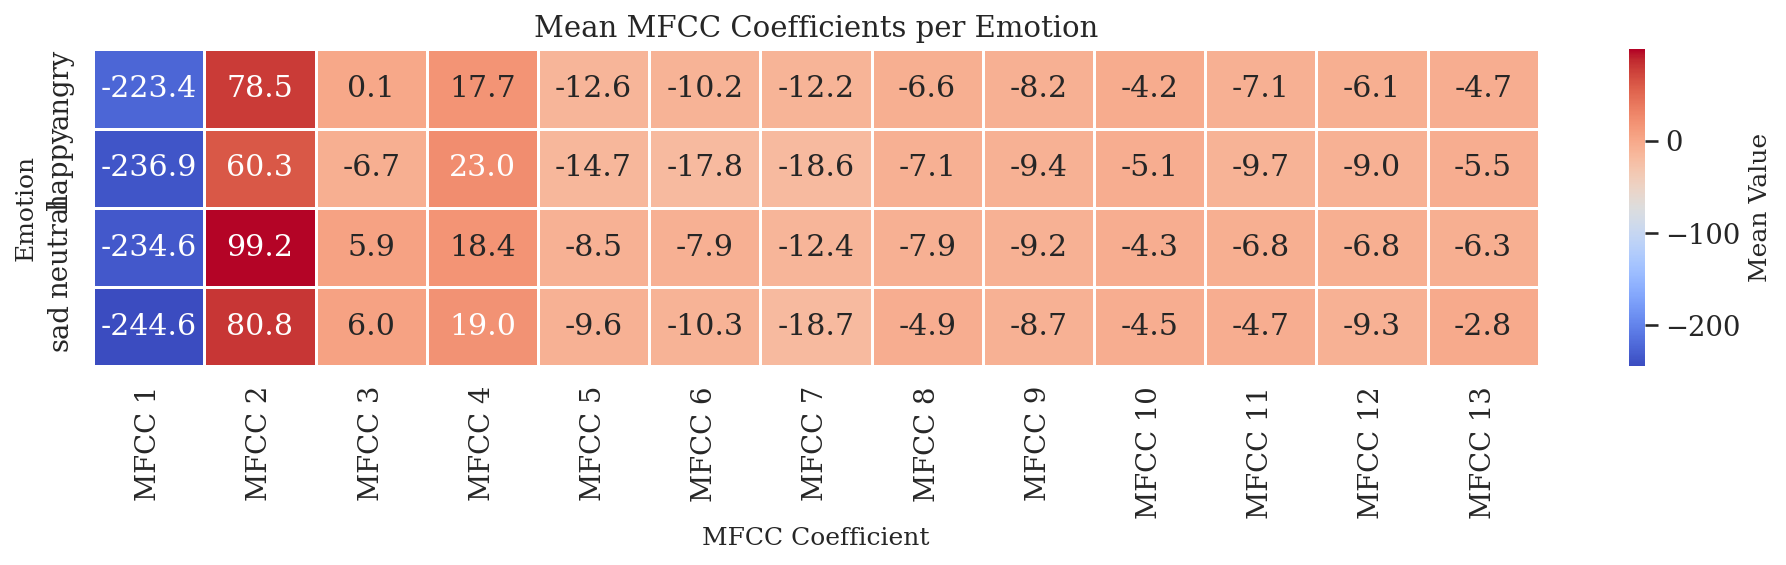

In [17]:
# MFCC heatmap
mfcc_cols = [f'mfcc{i+1}_mean' for i in range(13)]
mfcc_by_emo = master.groupby('emotion')[mfcc_cols].mean().reindex(EMOTION_ORDER)
mfcc_by_emo.columns = [f'MFCC {i+1}' for i in range(13)]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(mfcc_by_emo, annot=True, fmt='.1f', cmap='coolwarm', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
ax.set(title='Mean MFCC Coefficients per Emotion', ylabel='Emotion', xlabel='MFCC Coefficient')
fig.tight_layout()


In [ ]:
save(fig, 'mfcc_heatmap')

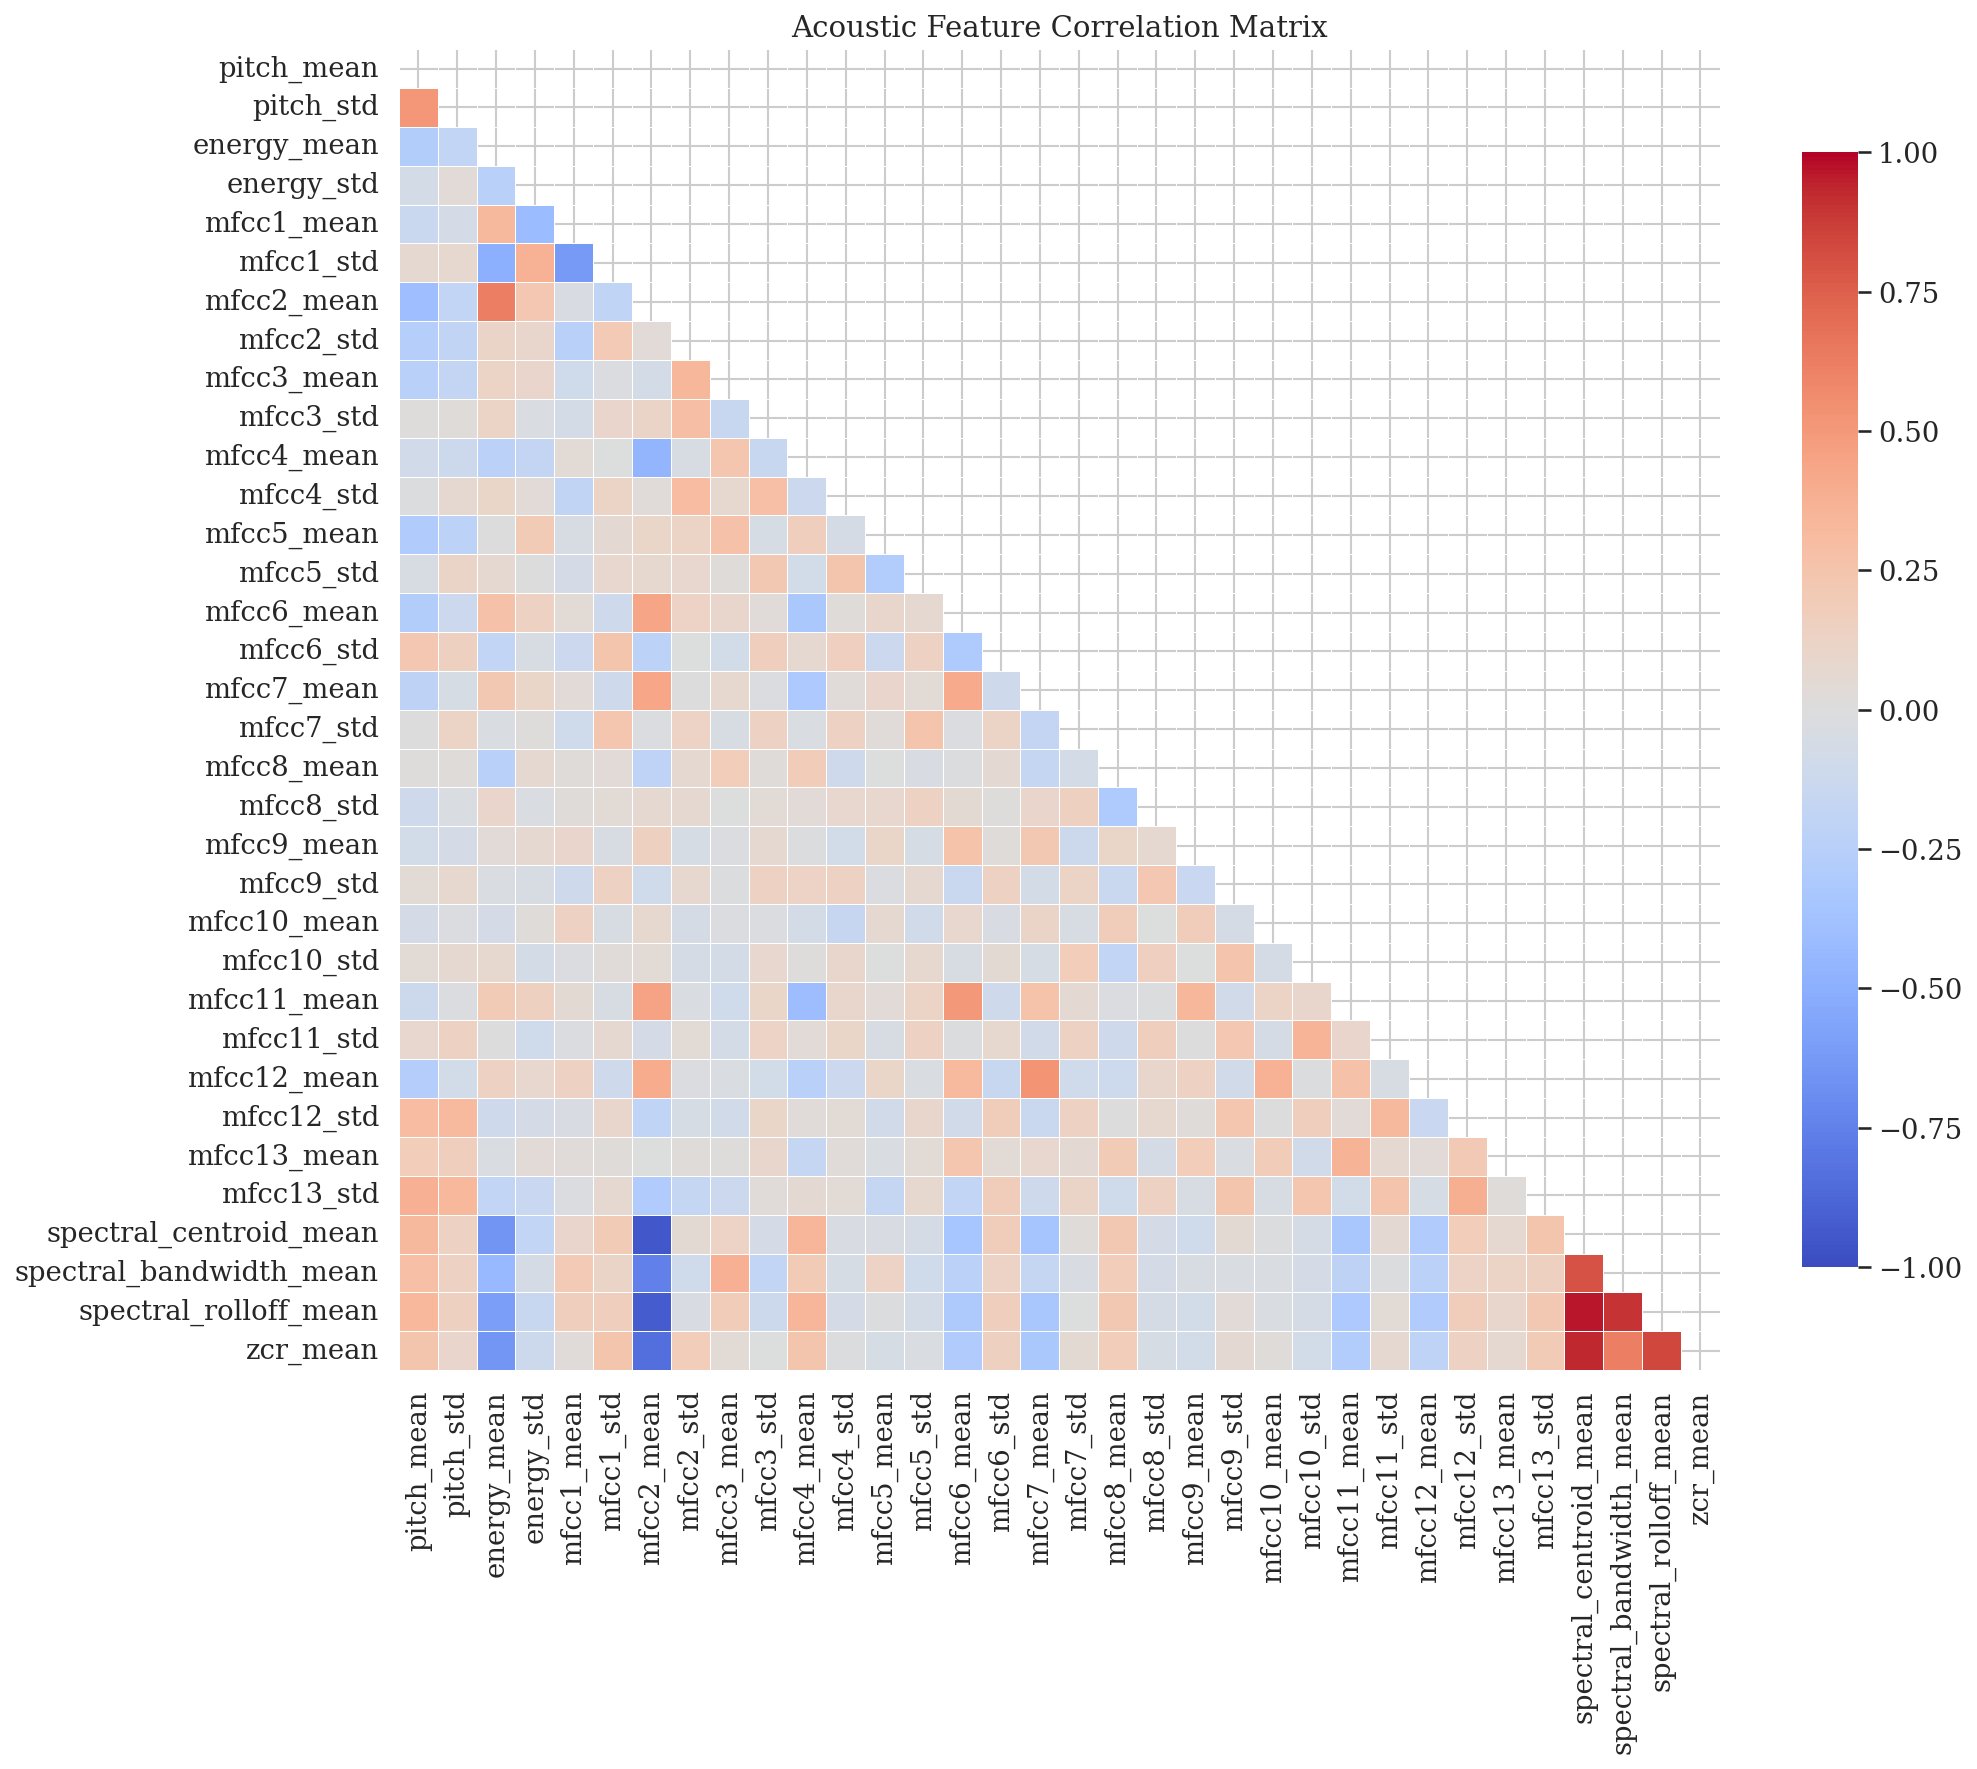

In [18]:
# Feature correlation matrix
corr = master[feat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Acoustic Feature Correlation Matrix')
fig.tight_layout()


In [ ]:
save(fig, 'feature_correlation_matrix')

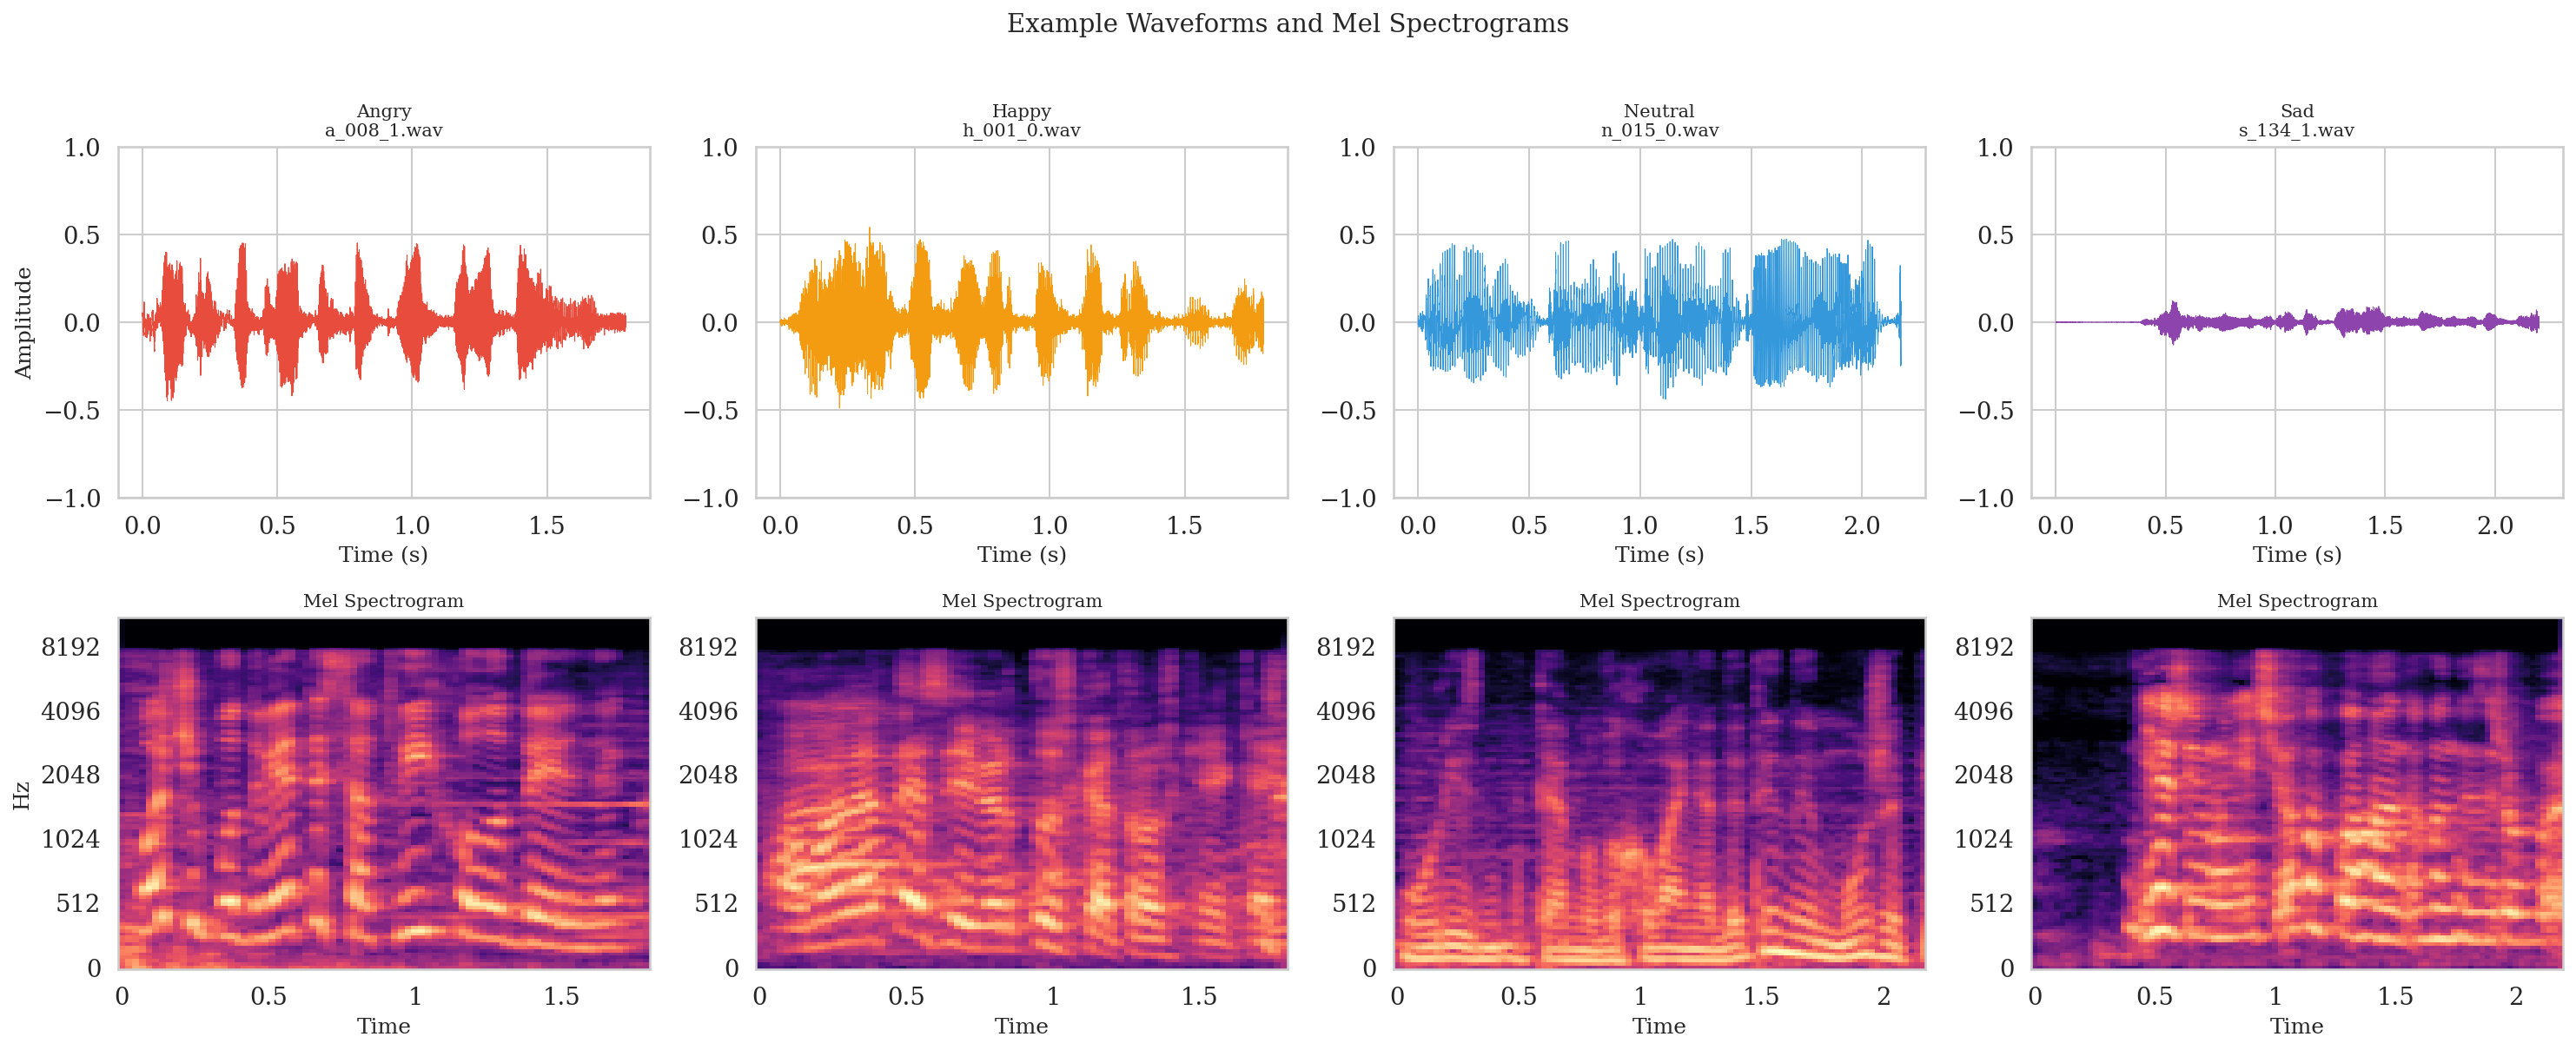

In [22]:
# Example waveforms + mel spectrograms (one representative clip per emotion)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, emo in enumerate(EMOTION_ORDER):
    sub    = df[df['emotion'] == emo]
    med    = sub['duration_seconds'].median()
    row    = sub.loc[(sub['duration_seconds'] - med).abs().idxmin()]
    fpath  = CLIPS_DIR / row['filename']
    y, sr  = librosa.load(str(fpath), sr=22050)

    t = np.linspace(0, len(y) / sr, len(y))
    axes[0, i].plot(t, y, color=EMOTION_COLORS[emo], linewidth=0.5)
    axes[0, i].set_title(f"{emo.capitalize()}\n{row['filename']}", fontsize=10)
    axes[0, i].set(xlabel='Time (s)', ylim=(-1, 1))
    if i == 0:
        axes[0, i].set_ylabel('Amplitude')

    S_dB = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128), ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel',
                             ax=axes[1, i], cmap='magma')
    axes[1, i].set_title('Mel Spectrogram', fontsize=10)
    if i != 0:
        axes[1, i].set_ylabel('')

fig.suptitle('Example Waveforms and Mel Spectrograms', fontsize=14, y=1.01)
fig.tight_layout()


In [ ]:
save(fig, 'example_spectrograms')

## 6. Dimensionality Reduction

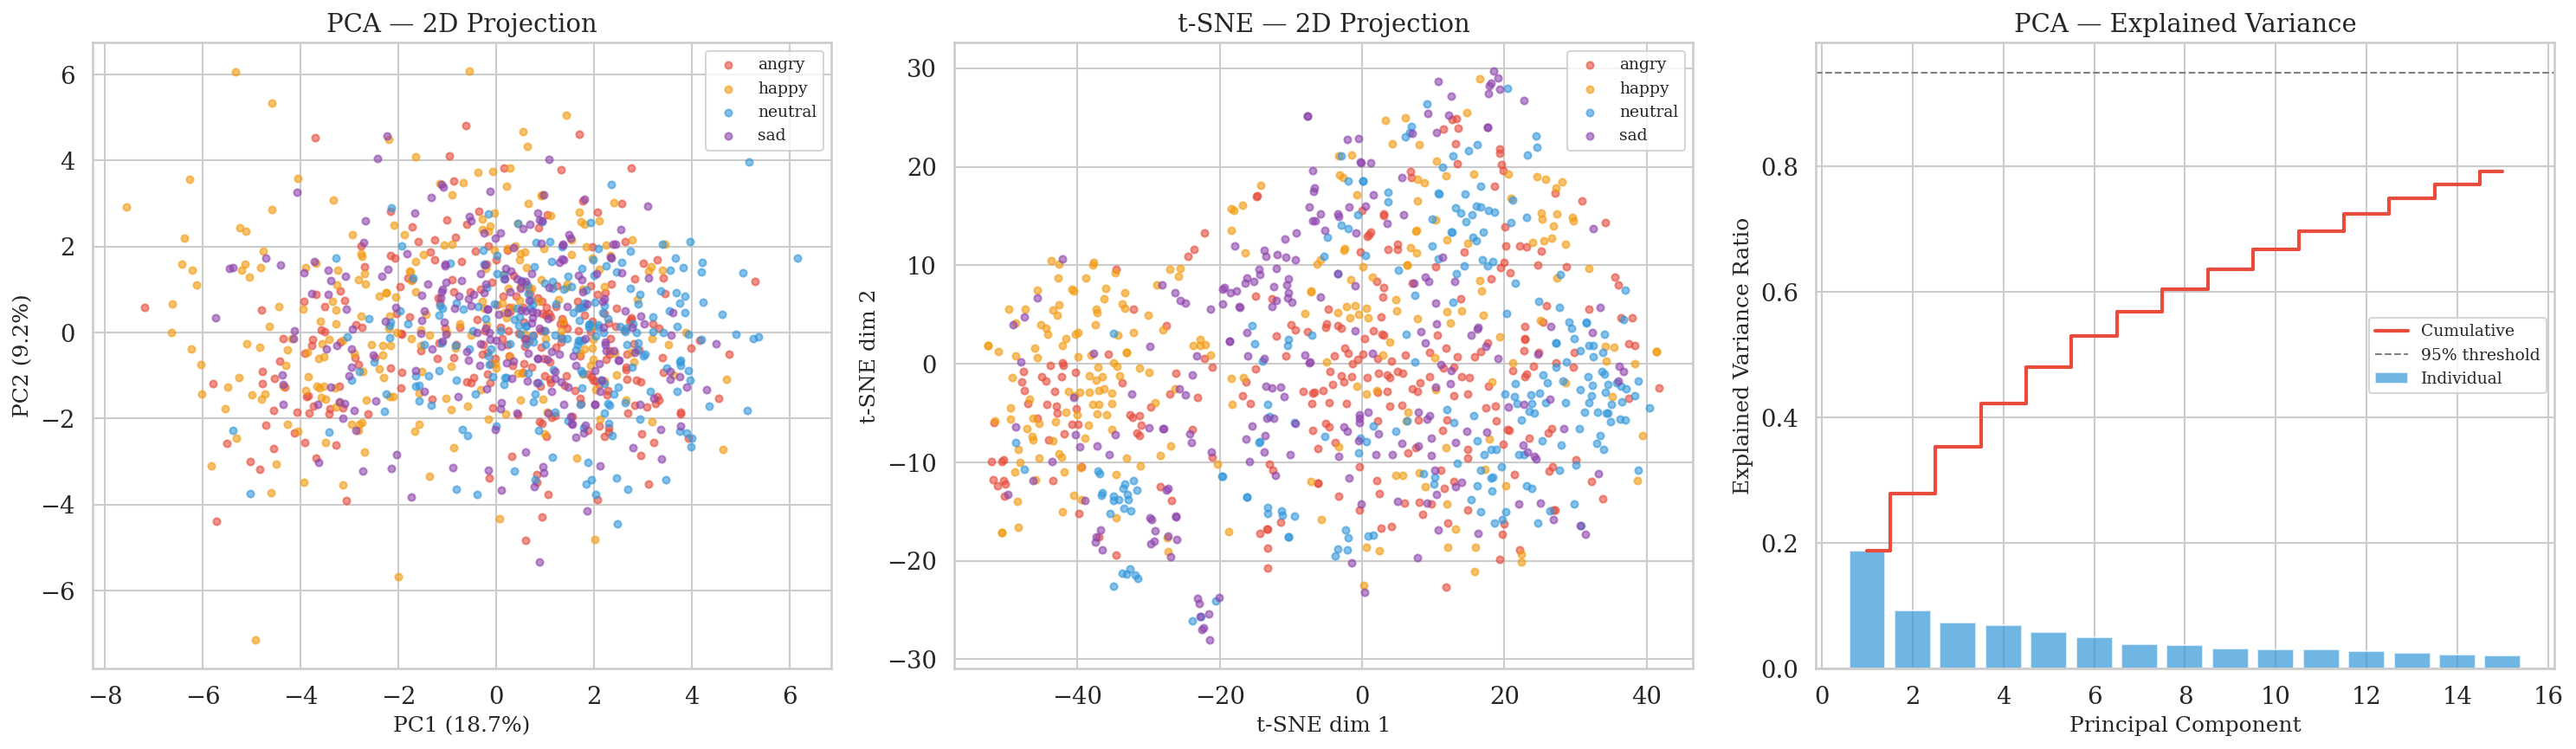

In [20]:
X      = master[feat_cols].values
labels = master['emotion'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X_scaled)

tsne   = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for emo in EMOTION_ORDER:
    mask = labels == emo
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=15, alpha=0.6,
                    color=EMOTION_COLORS[emo], label=emo)
axes[0].set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
            ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
            title='PCA — 2D Projection')
axes[0].legend(fontsize=9)

for emo in EMOTION_ORDER:
    mask = labels == emo
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=15, alpha=0.6,
                    color=EMOTION_COLORS[emo], label=emo)
axes[1].set(xlabel='t-SNE dim 1', ylabel='t-SNE dim 2', title='t-SNE — 2D Projection')
axes[1].legend(fontsize=9)

pca_full = PCA().fit(X_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
nc       = np.arange(1, len(cum_var) + 1)
axes[2].bar(nc[:15], pca_full.explained_variance_ratio_[:15], color='#3498db', alpha=0.7, label='Individual')
axes[2].step(nc[:15], cum_var[:15], where='mid', color='#e74c3c', linewidth=2, label='Cumulative')
axes[2].axhline(0.95, color='gray', linestyle='--', linewidth=1, label='95% threshold')
axes[2].set(xlabel='Principal Component', ylabel='Explained Variance Ratio',
            title='PCA — Explained Variance')
axes[2].legend(fontsize=9)

fig.tight_layout()


In [ ]:
save(fig, 'dimensionality_reduction')

In [21]:
# Summary: reproduce key numbers from the thesis
n_sig      = (kw_df['p'] < 0.05).sum()
top1       = kw_df.iloc[0]
dur_med    = df['duration_seconds'].median()
imb        = counts.max() / counts.min()
female_pct = (df['gender'] == 'female').mean() * 100

print('=== Thesis consistency check ===')
print(f'Total samples:         {len(df)}          (thesis: 952)')
print(f'Imbalance ratio:       {imb:.2f}         (thesis: 1.17)')
print(f'Female:                {female_pct:.1f}%        (thesis: 62.3%)')
print(f'Median duration:       {dur_med:.2f}s       (thesis: ~2s)')
print(f'Significant features:  {n_sig}/34        (thesis: 30/34)')
print(f'Top feature:           {top1["feature"]}  ε²={top1["eps2"]:.3f}  (thesis: pitch_mean ε²=0.160)')

=== Thesis consistency check ===
Total samples:         952          (thesis: 952)
Imbalance ratio:       1.17         (thesis: 1.17)
Female:                62.3%        (thesis: 62.3%)
Median duration:       1.99s       (thesis: ~2s)
Significant features:  30/34        (thesis: 30/34)
Top feature:           pitch_mean  ε²=0.160  (thesis: pitch_mean ε²=0.160)
